# IPL Data Analysis – Fun with NumPy, Pandas & Matplotlib 🏏

Welcome to this interactive data science journey! Today, we aren't just looking at numbers; we are looking at the pulse of India — **IPL 2023!**

### 🌟 Why are we here?
- “Who is the real GOAT of IPL?”
- “CSK vs MI — what does the data actually say?”
- Can we predict a winner based on the toss?

### 🤔 Warm-up Questions:
1. Which team do you support? (Be honest! 😄)
2. Who was the highest run-getter in 2023?
3. Does winning the toss actually help in winning the match?

Let's dive in! 🚀

## 🔹 SECTION 1: Load & Explore Data

Before we can analyze, we must "summon" our data using **Pandas**. Think of Pandas as Excel on steroids.

We will use:
- `read_csv()`: To load the data.
- `.head()`: To see the top rows.
- `.shape`: To see how big our dataset is.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the datasets
matches = pd.read_csv('each_match_records.csv')
balls = pd.read_csv('each_ball_records.csv')

print("Data Loaded Successfully!")
print(f"Matches Dataset Shape: {matches.shape}")
print(f"Ball-by-Ball Dataset Shape: {balls.shape}")

Data Loaded Successfully!
Matches Dataset Shape: (74, 18)
Ball-by-Ball Dataset Shape: (17863, 9)


### 👉 Look at the first 5 rows
Run the cell below to see what our match data looks like. 
**Question:** What do you think each column means?

In [2]:
matches.head()

,season,date,match_number,match_type,venue,location,team1,team2,toss_won,toss_decision,umpire1,umpire2,reserve_umpire,match_referee,winner,winner_runs,winner_wickets,man_of_match
0,2023,31-03-2023,1,Group,Narendra Modi Stadium,Ahmedabad,Chennai Super Kings,Gujarat Titans,Gujarat Titans,field,Nitin Menon,HAS Khalid,A Bengeri,J Srinath,Gujarat Titans,NaN,5.0,Rashid Khan
1,2023,01-04-2023,2,Group,Punjab Cricket Association IS Bindra Stadium,Chandigarh,Punjab Kings,Kolkata Knight Riders,Kolkata Knight Riders,field,BNJ Oxenford,YC Barde,PM Joshi,M Nayyar,Punjab Kings,7.0,NaN,Arshdeep Singh
2,2023,01-04-2023,3,Group,Bharat Ratna Shri Atal Bihari Vajpayee Ekana C...,Lucknow,Lucknow Super Giants,Delhi Capitals,Delhi Capitals,field,AK Chaudhary,NA Patwardhan,M Kuppuraj,DS Manohar,Lucknow Super Giants,50.0,NaN,MA Wood
3,2023,02-04-2023,4,Group,Rajiv Gandhi International Stadium,Hyderabad,Rajasthan Royals,Sunrisers Hyderabad,Sunrisers Hyderabad,field,KN Ananthapadmanabhan,R Pandit,Abhijit Bhattacharya,V Narayan Kutty,Rajasthan Royals,72.0,NaN,JC Buttler
4,2023,02-04-2023,5,Group,M Chinnaswamy Stadium,Bengaluru,Mumbai Indians,Royal Challengers Bangalore,Royal Challengers Bangalore,field,Nitin Menon,Tapan Sharma,A Bengeri,J Srinath,Royal Challengers Bangalore,NaN,8.0,F du Plessis


## 🔹 SECTION 2: Understanding the Dataset

We have two main files:
1. **Match-level data (`matches`)**: Contains overall summary of each game (Who played, who won, where it happened).
2. **Ball-by-ball data (`balls`)**: Every single delivery bowled in the tournament! (Who bowled, who practiced, runs scored).

### 📝 Activity:
How many matches are in our dataset?

In [4]:
total_matches = len(matches)
print(f"Total matches played in IPL 2023: {total_matches}")

Total matches played in IPL 2023: 74


## 🔹 SECTION 3: Basic Pandas Operations (Hands-on)

Let's learn how to filter and count things.
- `value_counts()`: Counts unique occurrences.
- `groupby()`: Groups data for comparison.

### 🏠 Most Frequent Venue
Where were most matches played?

In [5]:
venue_counts = matches['venue'].value_counts()
print("Top 5 Venues:")
print(venue_counts.head())

Top 5 Venues:
venue
Narendra Modi Stadium                                           9
MA Chidambaram Stadium                                          9
Bharat Ratna Shri Atal Bihari Vajpayee Ekana Cricket Stadium    7
Rajiv Gandhi International Stadium                              7
M Chinnaswamy Stadium                                           7
Name: count, dtype: int64


### 🪙 Toss Winners
Who won the most tosses?

In [5]:
toss_winners = matches['toss_won'].value_counts()
print(toss_winners)

toss_won
Rajasthan Royals               10
Chennai Super Kings            10
Mumbai Indians                 10
Gujarat Titans                  9
Royal Challengers Bangalore     8
Delhi Capitals                  7
Sunrisers Hyderabad             7
Kolkata Knight Riders           5
Punjab Kings                    5
Lucknow Super Giants            3
Name: count, dtype: int64


### 🏆 Mini Challenge: Top 3 Winning Teams
Can you find which teams won the most matches?

In [6]:
# Your turn! Find the top 3 winners
top_winners = matches['winner'].value_counts().head(3)
print("Top 3 Teams by Wins:")
print(top_winners)

Top 3 Teams by Wins:
winner
Gujarat Titans         11
Chennai Super Kings    10
Mumbai Indians          9
Name: count, dtype: int64


## 🔹 SECTION 4: NumPy in Action

Pandas is great for tables, but **NumPy** is the king of math! We can convert Pandas columns into NumPy arrays for lightning-fast calculations.

We will calculate:
- Total runs in the tournament.
- Average runs per match.

In [7]:
# Convert the 'score' column from ball data to a NumPy array
# Note: 'score' in ball-by-ball is runs on that delivery
runs_array = balls['score'].to_numpy()

# Note: Some scores might be strings like '1lb' or '1wd', 
# let's clean it or just use numeric part if needed. 
# For simplicity in this intro, we assume numeric or clean it.
# Actually, looking at ball_records, 'score' seems to be the numeric outcome.

total_runs_ipl = np.sum(balls[pd.to_numeric(balls['score'], errors='coerce').notnull()]['score'].astype(int))
avg_runs_per_delivery = np.mean(pd.to_numeric(balls['score'], errors='coerce').dropna())

print(f"Total Runs in IPL 2023: {total_runs_ipl}")
print(f"Average Runs per ball: {avg_runs_per_delivery:.2f}")

Total Runs in IPL 2023: 25684
Average Runs per ball: 1.44


### 🏆 Mini Challenge: Total Runs per Team
Let's see which team scored the most runs overall using NumPy logic.

In [8]:
# Quick GroupBy + Sum
team_runs = balls.groupby('batter')['score'].sum().sort_values(ascending=False)
print("Top Run Scorers (Batter):")
print(team_runs.head())

Top Run Scorers (Batter):
batter
Shubman Gill        916
Faf du Plessis      735
Devon Conway        684
Virat Kohli         657
Yashasvi Jaiswal    637
Name: score, dtype: int64


## 🔹 SECTION 5: BATTING ANALYSIS (🔥 ENGAGING)

Now for the fun part! Who dominated with the bat?

### 🟠 Top 10 Run Scorers

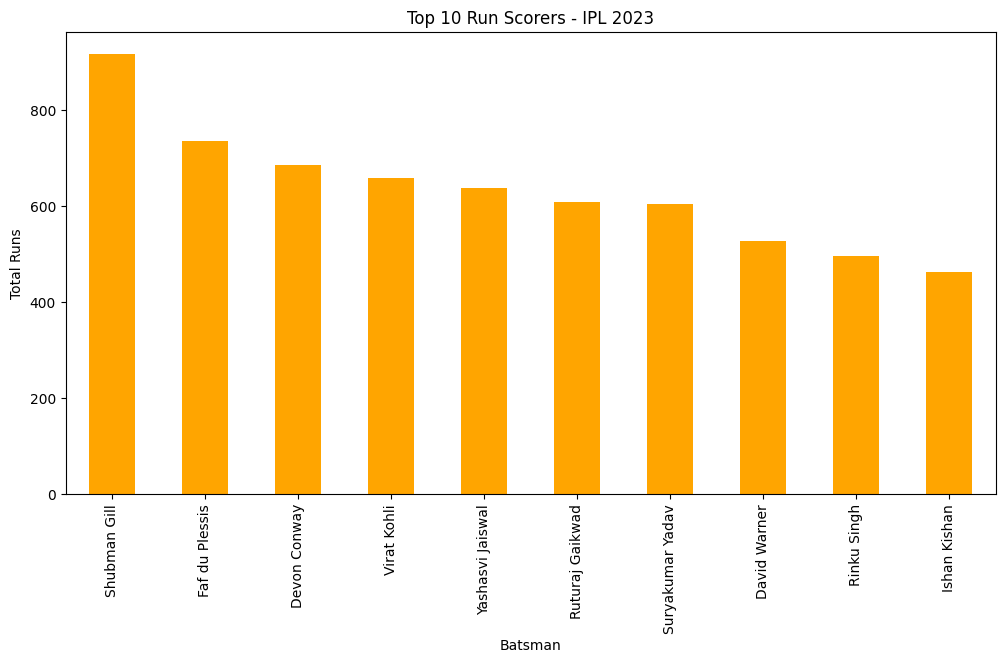

In [9]:
# Clean score to numeric for math
balls['score_numeric'] = pd.to_numeric(balls['score'], errors='coerce').fillna(0)

top_batsmen = balls.groupby('batter')['score_numeric'].sum().sort_values(ascending=False).head(10)

# Plotting
plt.figure(figsize=(12,6))
top_batsmen.plot(kind='bar', color='orange')
plt.title('Top 10 Run Scorers - IPL 2023')
plt.xlabel('Batsman')
plt.ylabel('Total Runs')
plt.show()

### 🥧 Run Distribution
How do batsmen get their runs? (1s, 2s, 4s, 6s)

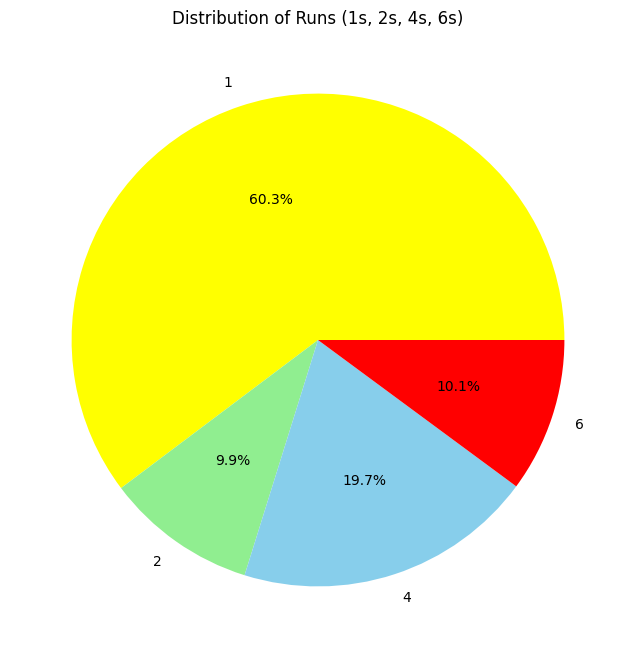

In [10]:
run_counts = balls['outcome'].value_counts()
# Filtering for just 1, 2, 4, 6
boundaries = run_counts.loc[['1', '2', '4', '6']]

plt.figure(figsize=(8,8))
plt.pie(boundaries.to_numpy(), labels=boundaries.index.to_list(), autopct='%1.1f%%', colors=['yellow', 'lightgreen', 'skyblue', 'red'])
plt.title('Distribution of Runs (1s, 2s, 4s, 6s)')
plt.show()

## 🔹 SECTION 6: BOWLING ANALYSIS

Bowling wins matches! Let's see who the "Purple Cap" contenders were.
(Note: Wickets are marked as 'w' in outcome)

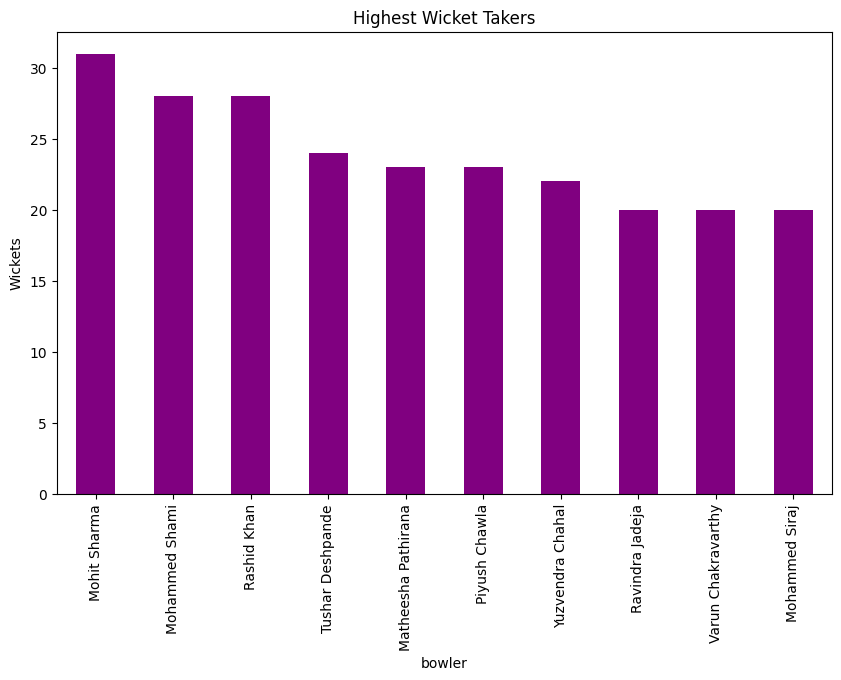

In [11]:
wickets = balls[balls['outcome'] == 'w']
top_bowlers = wickets.groupby('bowler').size().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
top_bowlers.plot(kind='bar', color='purple')
plt.title('Highest Wicket Takers')
plt.ylabel('Wickets')
plt.show()

## 🔹 SECTION 7: TEAM ANALYSIS (🔥 FAN WAR MODE)

Time for the ultimate debate: **CSK vs MI**! 💛 vs 💙

Let's see their win counts.

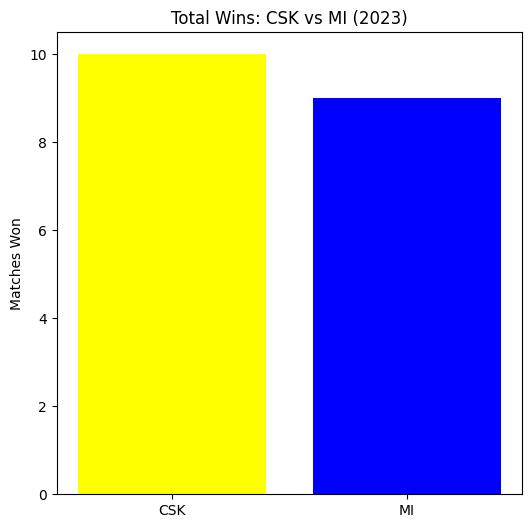

CSK Wins: 10
MI Wins: 9


In [12]:
csk_wins = len(matches[matches['winner'] == 'Chennai Super Kings'])
mi_wins = len(matches[matches['winner'] == 'Mumbai Indians'])

plt.figure(figsize=(6,6))
plt.bar(['CSK', 'MI'], [csk_wins, mi_wins], color=['yellow', 'blue'])
plt.title('Total Wins: CSK vs MI (2023)')
plt.ylabel('Matches Won')
plt.show()

print(f"CSK Wins: {csk_wins}")
print(f"MI Wins: {mi_wins}")

👉 **Commentary:** *“Let the debate begin 😄 MI fans might say they have more trophies, but CSK fans have the 2023 bragging rights!”*

## 🔹 SECTION 8: MATCH INSIGHTS

What was the general "vibe" of the matches? High scoring or low scoring?

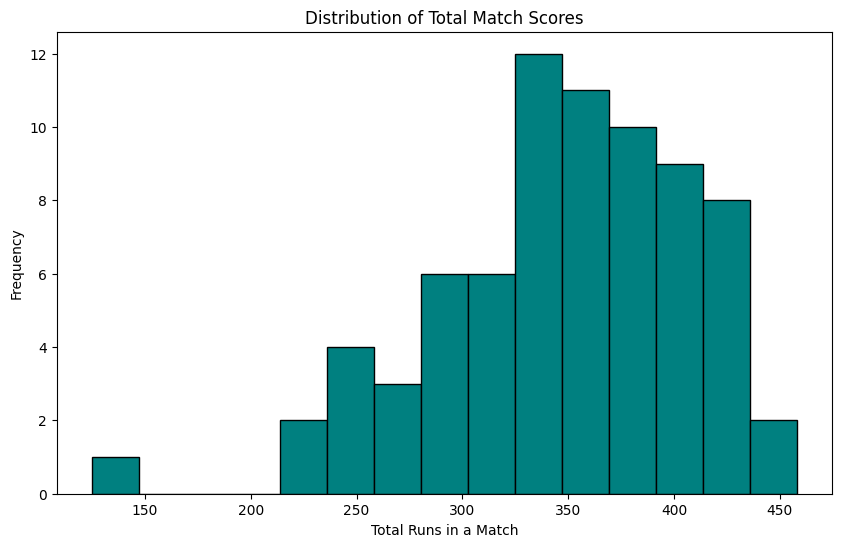

In [13]:
# Total runs per match
match_scores = balls.groupby(['match_no', 'inningno'])['score_numeric'].sum().reset_index()
# Total match score (both innings)
total_match_score = match_scores.groupby('match_no')['score_numeric'].sum()

plt.figure(figsize=(10,6))
plt.hist(total_match_score, bins=15, color='teal', edgecolor='black')
plt.title('Distribution of Total Match Scores')
plt.xlabel('Total Runs in a Match')
plt.ylabel('Frequency')
plt.show()

## 🔹 SECTION 9: VISUALIZATION MASTERY (Matplotlib)

We've used charts throughout, but remember these 4 pillars:
1. `plt.bar()`: Good for categories (Teams, Players).
2. `plt.pie()`: Good for parts of a whole (Run types).
3. `plt.hist()`: Good for distributions (Scores).
4. `plt.plot()`: Good for trends (not used yet, let's try!).

### Activity: Toss Decision Trend
Do teams prefer batting or fielding?

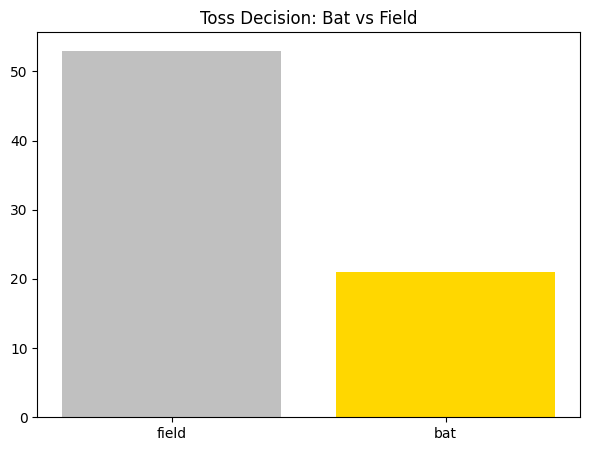

In [14]:
toss_decision = matches['toss_decision'].value_counts()

plt.figure(figsize=(7,5))
plt.bar(toss_decision.index.to_numpy(), toss_decision.to_numpy(), color=['silver', 'gold'])
plt.title('Toss Decision: Bat vs Field')
plt.show()

## 🔹 SECTION 10: MINI HACKATHON (🔥 YOUR TURN!)

Time to put on your Data Scientist hat! Answer these 5 questions using code:

1. **Find top 5 players with most 6s.**
2. **Which team won the most matches by runs (highest `winner_runs`)?**
3. **Find the venue with the highest average total score.**
4. **Compare Virat Kohli vs MS Dhoni runs.**
5. **Create a plot of your choice!**

In [15]:
# --- START YOUR CODE HERE ---

# 1. Top 5 players with most 6s
sixes = balls[balls['outcome'] == '6'].groupby('batter').size().sort_values(ascending=False).head(5)
print("Most Sixes:")
print(sixes)

# 2. Team with highest win margin by runs
max_run_win = matches.sort_values(by='winner_runs', ascending=False).iloc[0]
print(f"\nHighest run margin win: {max_run_win['winner']} by {max_run_win['winner_runs']} runs")

# --- END ---

Most Sixes:
batter
Faf du Plessis     36
Shivam Dube        35
Shubman Gill       32
Glenn Maxwell      31
Ruturaj Gaikwad    30
dtype: int64

Highest run margin win: Royal Challengers Bangalore by 112.0 runs


## 🔹 SECTION 11: FINAL INSIGHTS

After 2 hours of digging through data, what did we learn?
- **The Boss:** We identified the top scorers and wicket takers.
- **The Strategy:** Teams heavily prefer fielding first after winning the toss.
- **The Fun:** Data isn't just about boring spreadsheets; it's about stories!

**Final Thought:** *“Data analysis is FUN because it gives you the power to settle arguments with facts!”* 📊✨